## Importación de librerias

In [1]:
import geopandas as gpd
import pandas as pd

import json
from shapely.geometry import Point, shape

import matplotlib.pyplot as plt

import numpy as np

# Exploración de datos

## Archivo Límites de AGEB de zonas urbanas (Información del 2020)

Ninguna columna tiene celdas vacías

In [2]:
zonas_agebs_urban = gpd.read_file("data/lmites-de-ageb-urbanas-en-la-ciudad-de-mxico.json")
zonas_agebs_rural = gpd.read_file("data/lmites-de-ageb-rurales-en-la-ciudad-de-mxico.json")

zonas_agebs = pd.concat([zonas_agebs_urban, zonas_agebs_rural], ignore_index=True)
zonas_agebs = gpd.GeoDataFrame(zonas_agebs, geometry="geometry", crs=zonas_agebs_urban.crs)

zonas_agebs_proj = zonas_agebs.to_crs("EPSG:3857")
zonas_agebs["area_total"] = zonas_agebs_proj.geometry.area

zonas_agebs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2453 entries, 0 to 2452
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   CVEGEO      2453 non-null   str     
 1   CVE_ENT     2453 non-null   str     
 2   CVE_MUN     2453 non-null   str     
 3   CVE_LOC     2431 non-null   str     
 4   CVE_AGEB    2453 non-null   str     
 5   geometry    2453 non-null   geometry
 6   area_total  2453 non-null   float64 
dtypes: float64(1), geometry(1), str(5)
memory usage: 134.3 KB


In [3]:
zonas_agebs.head()

,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,CVE_AGEB,geometry,area_total
0,0901000011716,09,010,0001,1716,"POLYGON ((-99.25882 19.32558, -99.25834 19.325...",3.013332e+05
1,0901000012150,09,010,0001,2150,"POLYGON ((-99.1917 19.37893, -99.1917 19.37879...",2.493874e+05
2,0901000011133,09,010,0001,1133,"POLYGON ((-99.1776 19.35182, -99.17766 19.3517...",6.649929e+05
3,0901000011307,09,010,0001,1307,"POLYGON ((-99.20805 19.31277, -99.20768 19.312...",1.202184e+06
4,0901000010281,09,010,0001,0281,"POLYGON ((-99.24228 19.38451, -99.24233 19.384...",2.165112e+05


Gráfico del mapa de la CDMX con las zonas AGEB Urbanas

<Axes: >

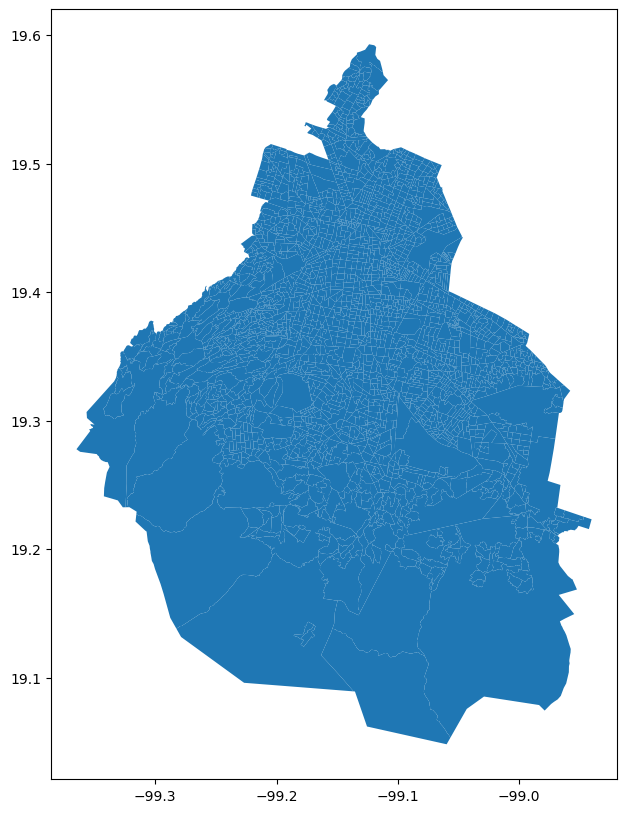

In [4]:
zonas_agebs.plot(figsize=(10, 10))

El dataset no cuenta con ninguna fila duplicada

In [5]:
zonas_agebs.duplicated().sum()

np.int64(0)

Se trabajará con todas las alcaldías de la CDMX para incorporar TODA la información disponible y evitar sesgos por recorte territorial. La variable de filtrado se mantiene solo para conservar compatibilidad con celdas posteriores.

In [6]:
alcaldias_interes = sorted(zonas_agebs['CVE_MUN'].astype(str).unique().tolist())
zonas_filtradas = zonas_agebs.copy()

Se conserva el universo completo de AGEB (urbanas y rurales) para asegurar cobertura total de la CDMX.

In [7]:
zonas_filtradas.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2453 entries, 0 to 2452
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   CVEGEO      2453 non-null   str     
 1   CVE_ENT     2453 non-null   str     
 2   CVE_MUN     2453 non-null   str     
 3   CVE_LOC     2431 non-null   str     
 4   CVE_AGEB    2453 non-null   str     
 5   geometry    2453 non-null   geometry
 6   area_total  2453 non-null   float64 
dtypes: float64(1), geometry(1), str(5)
memory usage: 134.3 KB


Debido a que es muy importante conocer el tipo de suelo que tiene cada zona, se debe conectar con otro dataset que contiene esa información.
Esto es debido a que las características del suelo contribuyen al nivel de riesgo que puede presentarse en una zona dependiendo del tipo de fenómeno

## Archivo de zonificacion geotecnica (Información del 2017)

Este dataset cuenta con solo 3 registros, ningúno con valores nulos.

In [8]:
gdf_suelo = gpd.read_file("data/zonificacion_geotecnica_2017.geojson")

gdf_suelo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   objectid    3 non-null      int32   
 1   fenomeno    3 non-null      str     
 2   taxonomia   3 non-null      str     
 3   r_p_v_e     3 non-null      str     
 4   intensidad  3 non-null      str     
 5   detalles    3 non-null      str     
 6   nombre      3 non-null      str     
 7   fuente      3 non-null      str     
 8   magni_uni   3 non-null      str     
 9   magni_num   3 non-null      int32   
 10  calle_y_nu  3 non-null      str     
 11  colonia     3 non-null      str     
 12  cve_mun     3 non-null      str     
 13  alcaldia    3 non-null      str     
 14  entidad     3 non-null      str     
 15  area_m2     3 non-null      float64 
 16  perime_m    3 non-null      float64 
 17  altitud     3 non-null      int32   
 18  geometry    3 non-null      geometry
dtypes: f

La columna más relevante es la "intensidad" ya que indica que características tiene la zona. En total hay 3 tipos de suelo:

* Zona I - Zona firme de lomas
    * Descripción: Formadas por rocas o suelos generalmente firmes que fueron depositados fuera del ambiente lacustre, pero en los que pueden existir, superficialmente o intercalados, depósitos arenosos en estado suelto o cohesivos relativamente blandos.

* Zona II - Zona de transición
    * Descripción: Los depósitos profundos se encuentran a 20 m de profundidad, o menos, y que está constituida predominantemente por estratos arenosos y limo arenosos intercalados con capas de arcilla lacustre.

* Zona III - Zona de lago
    * Descripción: Integrada por depósitos de arcilla altamente compresibles, separados por capas arenosas con contenido de limo o arcilla. Estas capas arenosas son en general medianamente compactas a muy compactas y de espesor variable de centímetros a varios metros

In [9]:
gdf_suelo.head()

,objectid,fenomeno,taxonomia,r_p_v_e,intensidad,detalles,nombre,fuente,magni_uni,magni_num,calle_y_nu,colonia,cve_mun,alcaldia,entidad,area_m2,perime_m,altitud,geometry
0,1,Geológico,Zonificación Geotécnica,Escenario,Zona III,Integrada por depósitos de arcilla altamente c...,Zona de lago,Normas Técnicas Complementarias para Diseño y ...,n/a,0,n/a,n/a,n/a,n/a,Ciudad de México,6.681231e+08,210769.53,0,"POLYGON ((503209.37 2167202.532, 497622.138 21..."
1,3,Geológico,Zonificación Geotécnica,Escenario,Zona II,Los depósitos profundos se encuentran a 20 m d...,Zona de transición,Normas Técnicas Complementarias para Diseño y ...,n/a,0,n/a,n/a,n/a,n/a,Ciudad de México,2.979016e+08,443179.48,0,"MULTIPOLYGON (((511931.137 2162742.282, 511843..."
2,2,Geológico,Zonificación Geotécnica,Escenario,Zona I,Formadas por rocas o suelos generalmente firme...,Zona firme de lomas,Normas Técnicas Complementarias para Diseño y ...,n/a,0,n/a,n/a,n/a,n/a,Ciudad de México,1.393378e+09,443131.00,0,"MULTIPOLYGON (((515760.302 2167166.974, 507823..."


Debido a que para el objetivo del proyecto no es relevante las direcciones o colonias en la CDMX, se eliminarán las columnas. Lo único importante es el tipo de zona y la cantidad de área cuadrada que tiene.

In [10]:
gdf_suelo = gdf_suelo.drop(columns=['fenomeno', 'taxonomia', 'r_p_v_e', 'detalles', 'nombre', 'fuente', 'magni_uni', 'magni_num', 'calle_y_nu', 'colonia', 'cve_mun', 'alcaldia', 'entidad'])

In [11]:
gdf_suelo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   objectid    3 non-null      int32   
 1   intensidad  3 non-null      str     
 2   area_m2     3 non-null      float64 
 3   perime_m    3 non-null      float64 
 4   altitud     3 non-null      int32   
 5   geometry    3 non-null      geometry
dtypes: float64(2), geometry(1), int32(2), str(1)
memory usage: 252.0 bytes


El dataset tampoco tiene ningún registro duplicado.

In [12]:
gdf_suelo.duplicated().sum()

np.int64(0)

Una vez filtrados los datos, el siguiente paso es enlazarlos con el dataset de las zonas AGEB urbanas. Debido a que el dataset de zonificación geotécnica no cuenta con una clave estandarizada (como la CVEGEO), la unión no puede hacerse de forma tabular simple; por ello, se recurre a un Join Espacial (Spatial Join).

Para que este proceso sea preciso, es fundamental que ambos conjuntos de datos compartan el mismo Sistema de Referencia de Coordenadas (CRS). Por estándar, los archivos GeoJSON utilizan coordenadas geográficas (WGS84), cuyas unidades son grados decimales (propios de sistemas GPS). Sin embargo, para realizar cálculos métricos exactos y asegurar que los polígonos encajen perfectamente, es necesario reproyectar los datos a un sistema de coordenadas proyectadas.

Esto permite pasar de una representación esférica de la Tierra a una representación en un "plano", donde las unidades de medida son metros.

In [13]:
gdf_suelo = gdf_suelo.to_crs(zonas_filtradas.crs)

gdf_suelo = gdf_suelo.rename(columns={'intensidad': 'tipo_suelo'})

gdf_suelo_clean = gdf_suelo[['tipo_suelo', 'geometry']]

zonas_ageb_final= gpd.sjoin(zonas_filtradas, gdf_suelo_clean, how='left', predicate='intersects')

zonas_ageb_final = zonas_ageb_final.drop(columns=['index_right'])

In [14]:
zonas_ageb_final.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 2959 entries, 0 to 2452
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   CVEGEO      2959 non-null   str     
 1   CVE_ENT     2959 non-null   str     
 2   CVE_MUN     2959 non-null   str     
 3   CVE_LOC     2931 non-null   str     
 4   CVE_AGEB    2959 non-null   str     
 5   geometry    2959 non-null   geometry
 6   area_total  2959 non-null   float64 
 7   tipo_suelo  2949 non-null   str     
dtypes: float64(1), geometry(1), str(6)
memory usage: 208.1 KB


Anteriormente solo existian 1018 registros y después unir los datasets, la cantidad aumentó a 1286 registros. Esto significa que hay áreas AGEB que tienen más de un tipo de suelo, por lo que se dejará solo la zona más peligrosa asociada a esa área. El nivel de peligro es:

1. Nivel Bajo - Zona I
2. Nivel Medio - Zona II
3. Nivel Alto - Zona III

In [15]:
orden_suelo = {'Zona III': 3, 'Zona II': 2, 'Zona I': 1}
zonas_ageb_final['tipo_suelo'] = zonas_ageb_final['tipo_suelo'].astype(str).str.strip()
zonas_ageb_final['tipo_suelo'] = zonas_ageb_final['tipo_suelo'].map(orden_suelo)

zonas_ageb_final = zonas_ageb_final.sort_values('tipo_suelo', ascending=False)
zonas_ageb_final = zonas_ageb_final.drop_duplicates(subset='CVEGEO', keep='first')

In [16]:
zonas_ageb_final.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 2453 entries, 1672 to 2452
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   CVEGEO      2453 non-null   str     
 1   CVE_ENT     2453 non-null   str     
 2   CVE_MUN     2453 non-null   str     
 3   CVE_LOC     2431 non-null   str     
 4   CVE_AGEB    2453 non-null   str     
 5   geometry    2453 non-null   geometry
 6   area_total  2453 non-null   float64 
 7   tipo_suelo  2443 non-null   float64 
dtypes: float64(2), geometry(1), str(5)
memory usage: 172.5 KB


In [17]:
zonas_ageb_final.head()

,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,CVE_AGEB,geometry,area_total,tipo_suelo
1672,0901500010023,09,015,0001,0023,"POLYGON ((-99.13493 19.46489, -99.13492 19.465...",189037.016295,3.0
1673,0901500010466,09,015,0001,0466,"POLYGON ((-99.16104 19.45535, -99.16126 19.454...",417107.791809,3.0
1674,0901500010926,09,015,0001,0926,"POLYGON ((-99.16987 19.428, -99.17053 19.42768...",250720.441422,3.0
1675,0901500011229,09,015,0001,1229,"POLYGON ((-99.14984 19.41468, -99.15006 19.413...",566255.448577,3.0
1676,0901500011290,09,015,0001,1290,"POLYGON ((-99.12742 19.41048, -99.1273 19.4100...",228865.019259,3.0


## Archivo Atlas de riesgo sismico (Información del 2019)

El dataset no cuenta con ninguna celda vacía.

In [18]:
sismos = pd.read_csv("data/atlas-de-riesgo-sismico.csv")
sismos.info()

<class 'pandas.DataFrame'>
RangeIndex: 4908 entries, 0 to 4907
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            4908 non-null   float64
 1   geo_point_2d  4908 non-null   str    
 2   geo_shape     4908 non-null   str    
 3   fenomeno      4908 non-null   str    
 4   taxonomia     4908 non-null   str    
 5   r_p_v_e       4908 non-null   str    
 6   intensidad    4908 non-null   str    
 7   descripcio    4908 non-null   str    
 8   fuente        4908 non-null   str    
 9   cvegeo        4908 non-null   str    
 10  alcaldia      4908 non-null   str    
 11  entidad       4908 non-null   str    
 12  area_m2       4908 non-null   float64
 13  perime_m      4908 non-null   float64
 14  int2          4908 non-null   int64  
dtypes: float64(3), int64(1), str(11)
memory usage: 575.3 KB


Los datos más relevantes son:
* Intensidad: Indica el nivel de peligro que se puede presentar en la zona en caso de un sismo.

* CVEGEO: Es la clave estándar que permite unirlo al dataset de las zonas AGEB.

* area_m2: Representa la porción afectada de toda la zona AGEB.

* int2: Es la representación numérica de Intensidad.

In [19]:
sismos.head()

,id,geo_point_2d,geo_shape,fenomeno,taxonomia,r_p_v_e,intensidad,descripcio,fuente,cvegeo,alcaldia,entidad,area_m2,perime_m,int2
0,1411.0,"19.4774588726,-99.214475378","{""type"": ""Polygon"", ""coordinates"": [[[-99.2139...",Geológicos,Sísmico,Peligro,Medio,AGEB localizado en las partes más altas de la ...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0900200010608,Azcapotzalco,Ciudad de México,177118.764865,2461.440128,3
1,1414.0,"19.4840766322,-99.0979827502","{""type"": ""Polygon"", ""coordinates"": [[[-99.0973...",Geológicos,Sísmico,Peligro,Muy Alto,AGEB localizado en las regiones donde antiguam...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0900500011487,Gustavo A. Madero,Ciudad de México,137484.944478,1753.723791,5
2,1422.0,"19.5219195307,-99.1340171776","{""type"": ""Polygon"", ""coordinates"": [[[-99.1337...",Geológicos,Sísmico,Peligro,Medio,AGEB localizado en las partes más altas de la ...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0900500012841,Gustavo A. Madero,Ciudad de México,84091.291297,1217.219854,3
3,1444.0,"19.3139677776,-99.1267177657","{""type"": ""Polygon"", ""coordinates"": [[[-99.1249...",Geológicos,Sísmico,Peligro,Muy Alto,AGEB localizado en las regiones donde antiguam...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0900300010893,Coyoacán,Ciudad de México,271118.866925,2108.201526,5
4,1450.0,"19.3107975267,-99.1707434555","{""type"": ""Polygon"", ""coordinates"": [[[-99.1719...",Geológicos,Sísmico,Peligro,Medio,AGEB localizado en las partes más altas de la ...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0900300011567,Coyoacán,Ciudad de México,69468.042776,1072.146834,3


No tiene ningún registro duplicado.

In [20]:
sismos.duplicated().sum()

np.int64(0)

Para poder trabajar con solo las alcaldías seleccionadas, se deben filtrar los datos y para ello se debe trabajar con CVEGEO.

Esta clave de 13 dígitos se divide en 4 partes:

1. Estado (Clave de entidad federativa): Los primeros 2 dígitos.
2. Municipio o Alcaldía: Los siguientes 3 dígitos.
3. Localidad: Los siguientes 4 dígitos.
4. AGEB: Los últimos 4 dígitos.

Y la parte que permite filtrar los datos es la de municipio o alcaldía.

In [21]:
sismos['cve_mun'] = sismos['cvegeo'].str.slice(2, 5)

sismos_alcaldias = sismos[sismos['cve_mun'].isin(alcaldias_interes)].copy()

In [22]:
sismos_alcaldias.info()

<class 'pandas.DataFrame'>
RangeIndex: 4908 entries, 0 to 4907
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            4908 non-null   float64
 1   geo_point_2d  4908 non-null   str    
 2   geo_shape     4908 non-null   str    
 3   fenomeno      4908 non-null   str    
 4   taxonomia     4908 non-null   str    
 5   r_p_v_e       4908 non-null   str    
 6   intensidad    4908 non-null   str    
 7   descripcio    4908 non-null   str    
 8   fuente        4908 non-null   str    
 9   cvegeo        4908 non-null   str    
 10  alcaldia      4908 non-null   str    
 11  entidad       4908 non-null   str    
 12  area_m2       4908 non-null   float64
 13  perime_m      4908 non-null   float64
 14  int2          4908 non-null   int64  
 15  cve_mun       4908 non-null   str    
dtypes: float64(3), int64(1), str(12)
memory usage: 613.6 KB


Hay varias columnas que no son necesarias para el objetivo del proyecto, por lo que se eliminaran para reducir la cantidad de memoria consumida.

In [23]:
sismos_alcaldias.drop(columns=['fenomeno', 'taxonomia', 'r_p_v_e', 'fuente', 'alcaldia', 'entidad','descripcio', 'cve_mun'], inplace=True)

In [24]:
sismos_alcaldias.info()

<class 'pandas.DataFrame'>
RangeIndex: 4908 entries, 0 to 4907
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            4908 non-null   float64
 1   geo_point_2d  4908 non-null   str    
 2   geo_shape     4908 non-null   str    
 3   intensidad    4908 non-null   str    
 4   cvegeo        4908 non-null   str    
 5   area_m2       4908 non-null   float64
 6   perime_m      4908 non-null   float64
 7   int2          4908 non-null   int64  
dtypes: float64(3), int64(1), str(4)
memory usage: 306.9 KB


De esta forma se puede determinar que la columna int2 se refiere al nivel de intensidad pero de forma numérica.

La escala sería:
1. Muy Bajo
2. Bajo
3. Medio
4. Alto
5. Muy alto

In [25]:
sismos_final = sismos_alcaldias.merge(
    zonas_ageb_final[['CVEGEO', 'tipo_suelo', 'area_total']],
    left_on='cvegeo',
    right_on='CVEGEO',
    how='left'
)

sismos_final['pct_afectacion_sismo'] = (sismos_final['area_m2'] / sismos_final['area_total']) * 100

sismos_final['pct_afectacion_sismo'] = sismos_final['pct_afectacion_sismo'].clip(upper=100)


In [26]:
sismos_final = sismos_alcaldias.merge(
    zonas_ageb_final[['CVEGEO', 'tipo_suelo', 'area_total']],
    left_on='cvegeo',
    right_on='CVEGEO',
    how='left'
)

sismos_final['pct_afectacion_sismo'] = (sismos_final['area_m2'] / sismos_final['area_total']) * 100

sismos_final['pct_afectacion_sismo'] = sismos_final['pct_afectacion_sismo'].clip(upper=100)

sismos_final = sismos_final.sort_values(
    ['cvegeo', 'tipo_suelo'],
    ascending=[True, False]
)

sismos_ageb_unico = sismos_final.drop_duplicates(subset='cvegeo', keep='first').copy()

sismos_ageb_unico = sismos_ageb_unico.drop(columns=['CVEGEO', 'tipo_suelo', 'area_total'])

print(f"Registros finales: {len(sismos_ageb_unico)}")
print(sismos_ageb_unico[['cvegeo', 'pct_afectacion_sismo']].head())

Registros finales: 2454
             cvegeo  pct_afectacion_sismo
4144  0900200010010             88.311291
3039  0900200010025             88.256333
1396  090020001003A             85.427115
925   0900200010044             88.314352
1393  0900200010097             91.343819


Se trabaja con todas las AGEB disponibles. Las diferencias entre padrones de distintos anios se conservan y se documentan en el analisis, en lugar de eliminar registros manualmente.

In [27]:
sismos_ageb_unico.info()

<class 'pandas.DataFrame'>
Index: 2454 entries, 4144 to 2077
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    2454 non-null   float64
 1   geo_point_2d          2454 non-null   str    
 2   geo_shape             2454 non-null   str    
 3   intensidad            2454 non-null   str    
 4   cvegeo                2454 non-null   str    
 5   area_m2               2454 non-null   float64
 6   perime_m              2454 non-null   float64
 7   int2                  2454 non-null   int64  
 8   pct_afectacion_sismo  2452 non-null   float64
dtypes: float64(4), int64(1), str(4)
memory usage: 191.7 KB


Para resolver esta diferencia de tamaños, lo que se hará es descartar ese registro, puesto que elimintar un solo registro no representa una reducción de datos significativa para el modelo.

In [28]:
set_zonas = set(zonas_ageb_final['CVEGEO'].unique())
set_sismos = set(sismos_ageb_unico['cvegeo'].unique())

diferencia = set_sismos - set_zonas
print(f"Registros de sismo sin match en AGEB: {len(diferencia)}")

Registros de sismo sin match en AGEB: 2


In [29]:
sismos_ageb_unico = sismos_ageb_unico[sismos_ageb_unico['cvegeo'].isin(set_zonas)].copy()

print(f"Total de registros finales confirmados: {len(sismos_ageb_unico)}")

Total de registros finales confirmados: 2452


In [30]:
sismos_ageb_unico.info()

<class 'pandas.DataFrame'>
Index: 2452 entries, 4144 to 2077
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    2452 non-null   float64
 1   geo_point_2d          2452 non-null   str    
 2   geo_shape             2452 non-null   str    
 3   intensidad            2452 non-null   str    
 4   cvegeo                2452 non-null   str    
 5   area_m2               2452 non-null   float64
 6   perime_m              2452 non-null   float64
 7   int2                  2452 non-null   int64  
 8   pct_afectacion_sismo  2452 non-null   float64
dtypes: float64(4), int64(1), str(4)
memory usage: 191.6 KB


Para poder representar el nivel de riesgo en las zonas AGEB dentro de un mapa de la CDMX, es necesario que la columna geometry sea un objeto geométrico para manipularlo con un sistema de coordenadas.

In [31]:
def parse_geometry(x):
    try:
        if isinstance(x, str):
            return shape(json.loads(x))
        elif isinstance(x, dict):
            return shape(x)
        return None
    except:
        return None

Representación de toda la CDMX

<Axes: >

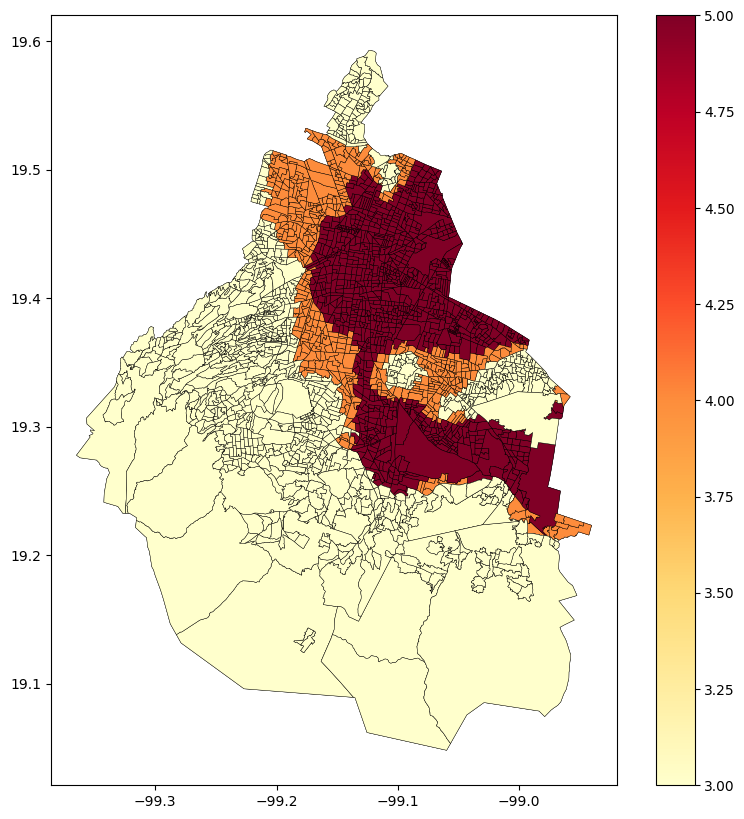

In [32]:
sismos['geometry'] = sismos['geo_shape'].apply(parse_geometry)

sismos_gdf = gpd.GeoDataFrame(sismos, geometry='geometry')

sismos_gdf.crs = "EPSG:4326"

sismos_gdf.plot(column='int2', cmap='YlOrRd', figsize=(10, 10), edgecolor='black', linewidth=0.3, legend=True)

Representación de las 4 alcaldías

<Axes: >

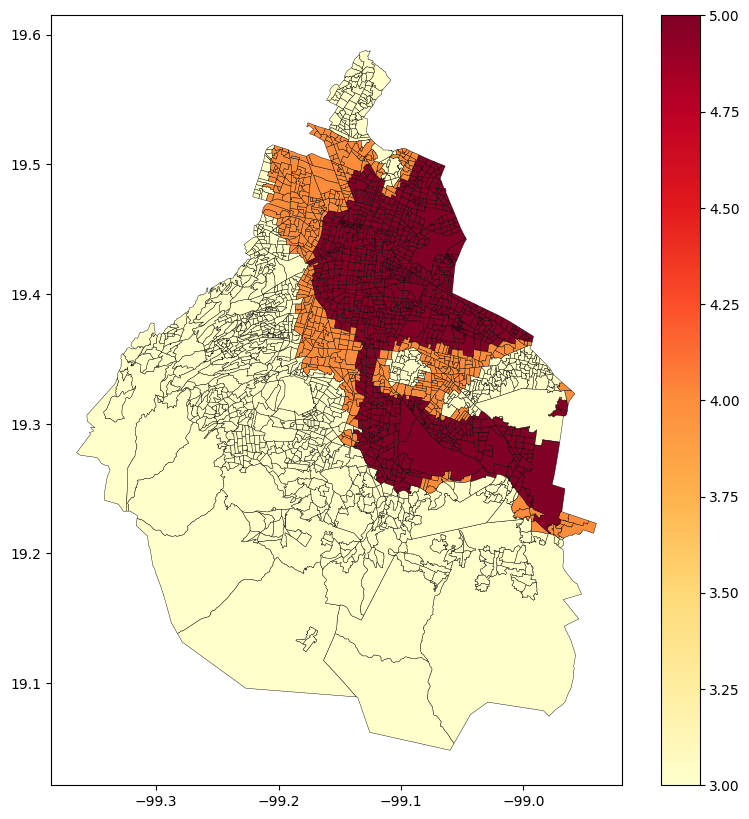

In [33]:
sismos_ageb_unico['geometry'] = sismos_ageb_unico['geo_shape'].apply(parse_geometry)

sismos_gdf = gpd.GeoDataFrame(sismos_ageb_unico, geometry='geometry')

sismos_gdf.crs = "EPSG:4326"

sismos_gdf.plot(column='int2', cmap='YlOrRd', figsize=(10, 10), edgecolor='black', linewidth=0.3, legend=True)

## Archivo Inundaciones (Información del 2019)

No tiene ningúna celda vacía.

In [34]:
inundaciones = pd.read_csv("data/atlas-de-riesgo-inundaciones.csv")

inundaciones.info()

<class 'pandas.DataFrame'>
RangeIndex: 4908 entries, 0 to 4907
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            4908 non-null   float64
 1   geo_point_2d  4908 non-null   str    
 2   geo_shape     4908 non-null   str    
 3   fenomeno      4908 non-null   str    
 4   taxonomia     4908 non-null   str    
 5   r_p_v_e       4908 non-null   str    
 6   intensidad    4908 non-null   str    
 7   descripcio    4908 non-null   str    
 8   fuente        4908 non-null   str    
 9   cvegeo        4908 non-null   str    
 10  alcaldia      4908 non-null   str    
 11  entidad       4908 non-null   str    
 12  area_m2       4908 non-null   float64
 13  perime_m      4908 non-null   float64
 14  period_ret    4908 non-null   str    
 15  intens_uni    4908 non-null   str    
 16  intens_num    4908 non-null   str    
 17  int2          4908 non-null   int64  
dtypes: float64(3), int64(1), str(14)
memory

Los datos más relevante son:

* Intensidad: Representa el nivel de peligro (de forma categórica) que tiene una zona al presentarse una inundación.

* area_m2: Indica el área afectada

* intens_num: Indica el porcentaje del área que se puede inundar.

* int2: Indica la intensidad pero de forma numérica.

In [35]:
inundaciones.head()

,id,geo_point_2d,geo_shape,fenomeno,taxonomia,r_p_v_e,intensidad,descripcio,fuente,cvegeo,alcaldia,entidad,area_m2,perime_m,period_ret,intens_uni,intens_num,int2
0,35.0,"19.2422518066,-99.0731823535","{""type"": ""Polygon"", ""coordinates"": [[[-99.0760...",Hidrometeorológicos,Inundaciones,Peligro,Bajo,Análisis del índice de Inundabilidad de la CON...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0901300011154,Xochimilco,Ciudad de México,973904.029201,6805.448256,5 años,% de area inundable,26 a 49,2
1,56.0,"19.2236128042,-99.1083418839","{""type"": ""Polygon"", ""coordinates"": [[[-99.1064...",Hidrometeorológicos,Inundaciones,Peligro,Muy Bajo,Análisis del índice de Inundabilidad de la CON...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0901300010601,Xochimilco,Ciudad de México,795548.364401,4693.752691,5 años,% de area inundable,0 a 25,1
2,32.0,"19.3809650541,-99.1373113251","{""type"": ""Polygon"", ""coordinates"": [[[-99.1366...",Hidrometeorológicos,Inundaciones,Peligro,Muy Alto,Análisis del índice de Inundabilidad de la CON...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0901400010524,Benito Juárez,Ciudad de México,168263.324089,1712.409605,5 años,% de area inundable,100,5
3,45.0,"19.2603567,-99.0628861422","{""type"": ""Polygon"", ""coordinates"": [[[-99.0614...",Hidrometeorológicos,Inundaciones,Peligro,Muy Alto,Análisis del índice de Inundabilidad de la CON...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0901300010724,Xochimilco,Ciudad de México,267499.368896,2488.603256,5 años,% de area inundable,100,5
4,31.0,"19.3905750675,-99.144452701","{""type"": ""Polygon"", ""coordinates"": [[[-99.1445...",Hidrometeorológicos,Inundaciones,Peligro,Muy Alto,Análisis del índice de Inundabilidad de la CON...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0901400010280,Benito Juárez,Ciudad de México,202062.408324,2113.713857,5 años,% de area inundable,100,5


In [36]:
inundaciones.drop(columns=['fenomeno', 'taxonomia', 'r_p_v_e', 'fuente', 'alcaldia', 'entidad','descripcio', 'period_ret', 'intens_uni'], inplace=True)

In [37]:
inundaciones.info()

<class 'pandas.DataFrame'>
RangeIndex: 4908 entries, 0 to 4907
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            4908 non-null   float64
 1   geo_point_2d  4908 non-null   str    
 2   geo_shape     4908 non-null   str    
 3   intensidad    4908 non-null   str    
 4   cvegeo        4908 non-null   str    
 5   area_m2       4908 non-null   float64
 6   perime_m      4908 non-null   float64
 7   intens_num    4908 non-null   str    
 8   int2          4908 non-null   int64  
dtypes: float64(3), int64(1), str(5)
memory usage: 345.2 KB


No tiene ningún registro duplicado.

In [38]:
inundaciones.duplicated().sum()

np.int64(0)

En este dataset también se tienen que filtrar los datos de las alcaldías seleccionadas.

In [39]:
inundaciones['cve_mun'] = inundaciones['cvegeo'].str.slice(2, 5)

inundaciones_alcaldias = inundaciones[inundaciones['cve_mun'].isin(alcaldias_interes)].copy()

inundaciones_alcaldias.drop(columns=['cve_mun'], inplace=True)

In [40]:
inundaciones_alcaldias.info()

<class 'pandas.DataFrame'>
RangeIndex: 4908 entries, 0 to 4907
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            4908 non-null   float64
 1   geo_point_2d  4908 non-null   str    
 2   geo_shape     4908 non-null   str    
 3   intensidad    4908 non-null   str    
 4   cvegeo        4908 non-null   str    
 5   area_m2       4908 non-null   float64
 6   perime_m      4908 non-null   float64
 7   intens_num    4908 non-null   str    
 8   int2          4908 non-null   int64  
dtypes: float64(3), int64(1), str(5)
memory usage: 345.2 KB


La columna intens_num tiene información relevante porque indica un rango de porcentajes en los cuales se puede llegar a inundar el área, pero para poder trabajarla en el modelo, lo que se realizará es convertir esa cadena a números y obtener el promedio del porcentaje de inundación que puede llegar a tener esa área.

In [41]:
inundaciones_alcaldias['intens_num'].unique()

<StringArray>
['26 a 49', '0 a 25', '100', '50 a 72', '73 a 99']
Length: 5, dtype: str

In [42]:
def limpiar_intensidad_rango(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip()

    if ' a ' in valor:
        try:
            partes = valor.split(' a ')
            limite_inferior = float(partes[0])
            limite_superior = float(partes[1])
            return (limite_inferior + limite_superior) / 2
        except ValueError:
            return np.nan

    try:
        return float(valor)
    except ValueError:
        return np.nan

In [43]:
inundaciones_final = inundaciones_alcaldias.merge(
    zonas_ageb_final[['CVEGEO', 'area_total']],
    left_on='cvegeo',
    right_on='CVEGEO',
    how='left',
)

inundaciones_final['intens_num_limpia'] = inundaciones_final['intens_num'].apply(limpiar_intensidad_rango)

inundaciones_final['pct_afectacion_inundacion'] = (inundaciones_final['area_m2'] / inundaciones_final['area_total']) * 100
inundaciones_final['pct_afectacion_inundacion'] = inundaciones_final['pct_afectacion_inundacion'].clip(upper=100)

inundaciones_final = inundaciones_final.sort_values(
    ['cvegeo', 'intens_num_limpia'],
    ascending=[True, False],
)

inundaciones_final = inundaciones_final[inundaciones_final['cvegeo'].isin(set_zonas)].copy()
inundaciones_ageb_unico = inundaciones_final.drop_duplicates(subset='cvegeo', keep='first').copy()
inundaciones_ageb_unico = inundaciones_ageb_unico.drop(columns=['CVEGEO'])

print(f"Registros finales: {len(inundaciones_ageb_unico)}")
print(inundaciones_ageb_unico[['cvegeo', 'pct_afectacion_inundacion']].head())

Registros finales: 2452
             cvegeo  pct_afectacion_inundacion
1544  0900200010010                  88.311291
751   0900200010025                  88.256333
1343  090020001003A                  85.427115
233   0900200010044                  88.314352
501   0900200010097                  91.343819


In [44]:
inundaciones_ageb_unico.info()

<class 'pandas.DataFrame'>
Index: 2452 entries, 1544 to 1771
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         2452 non-null   float64
 1   geo_point_2d               2452 non-null   str    
 2   geo_shape                  2452 non-null   str    
 3   intensidad                 2452 non-null   str    
 4   cvegeo                     2452 non-null   str    
 5   area_m2                    2452 non-null   float64
 6   perime_m                   2452 non-null   float64
 7   intens_num                 2452 non-null   str    
 8   int2                       2452 non-null   int64  
 9   area_total                 2452 non-null   float64
 10  intens_num_limpia          2452 non-null   float64
 11  pct_afectacion_inundacion  2452 non-null   float64
dtypes: float64(6), int64(1), str(5)
memory usage: 249.0 KB


In [45]:
inundaciones_ageb_unico = inundaciones_ageb_unico[inundaciones_ageb_unico['cvegeo'].isin(set_zonas)].copy()

print(f"Total de registros finales: {len(inundaciones_ageb_unico)}")

Total de registros finales: 2452


In [46]:
inundaciones_ageb_unico.info()

<class 'pandas.DataFrame'>
Index: 2452 entries, 1544 to 1771
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         2452 non-null   float64
 1   geo_point_2d               2452 non-null   str    
 2   geo_shape                  2452 non-null   str    
 3   intensidad                 2452 non-null   str    
 4   cvegeo                     2452 non-null   str    
 5   area_m2                    2452 non-null   float64
 6   perime_m                   2452 non-null   float64
 7   intens_num                 2452 non-null   str    
 8   int2                       2452 non-null   int64  
 9   area_total                 2452 non-null   float64
 10  intens_num_limpia          2452 non-null   float64
 11  pct_afectacion_inundacion  2452 non-null   float64
dtypes: float64(6), int64(1), str(5)
memory usage: 249.0 KB


In [47]:
inundaciones_ageb_unico.head()

,id,geo_point_2d,geo_shape,intensidad,cvegeo,area_m2,perime_m,intens_num,int2,area_total,intens_num_limpia,pct_afectacion_inundacion
1544,1572.0,"19.5130115574,-99.2059655969","{""type"": ""MultiPolygon"", ""coordinates"": [[[[-9...",Alto,0900200010010,164250.261074,1800.990935,73 a 99,4,185990.102889,86.0,88.311291
751,1680.0,"19.5124988251,-99.2006113396","{""type"": ""MultiPolygon"", ""coordinates"": [[[[-9...",Alto,0900200010025,191779.015940,1972.712226,73 a 99,4,217297.738768,86.0,88.256333
1343,1666.0,"19.5100165458,-99.207901795","{""type"": ""Polygon"", ""coordinates"": [[[-99.2065...",Alto,090020001003A,180275.636520,1800.371783,73 a 99,4,211028.589865,86.0,85.427115
233,1976.0,"19.5097422086,-99.2029703405","{""type"": ""Polygon"", ""coordinates"": [[[-99.2052...",Muy Alto,0900200010044,215010.562377,2503.795451,100,5,243460.499625,100.0,88.314352
501,1585.0,"19.5068534212,-99.2069730797","{""type"": ""MultiPolygon"", ""coordinates"": [[[[-9...",Muy Alto,0900200010097,178129.086298,1766.654156,100,5,195009.457852,100.0,91.343819


Representación del nivel de riesgo de inundación en la CDMX.

<Axes: >

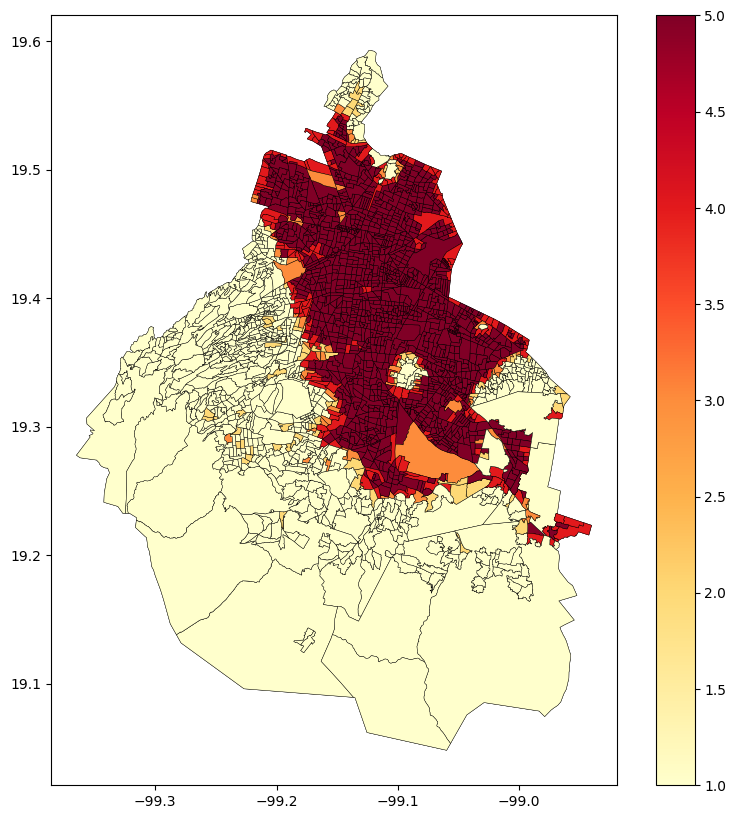

In [48]:
inundaciones['geometry'] = inundaciones['geo_shape'].apply(parse_geometry)

inundaciones_gdf = gpd.GeoDataFrame(inundaciones, geometry='geometry')

inundaciones_gdf.crs = "EPSG:4326"

inundaciones_gdf.plot(column='int2', cmap='YlOrRd', figsize=(10, 10), edgecolor='black', linewidth=0.3, legend=True)

Representación de riesgo en las alcaldías seleccionadas.

<Axes: >

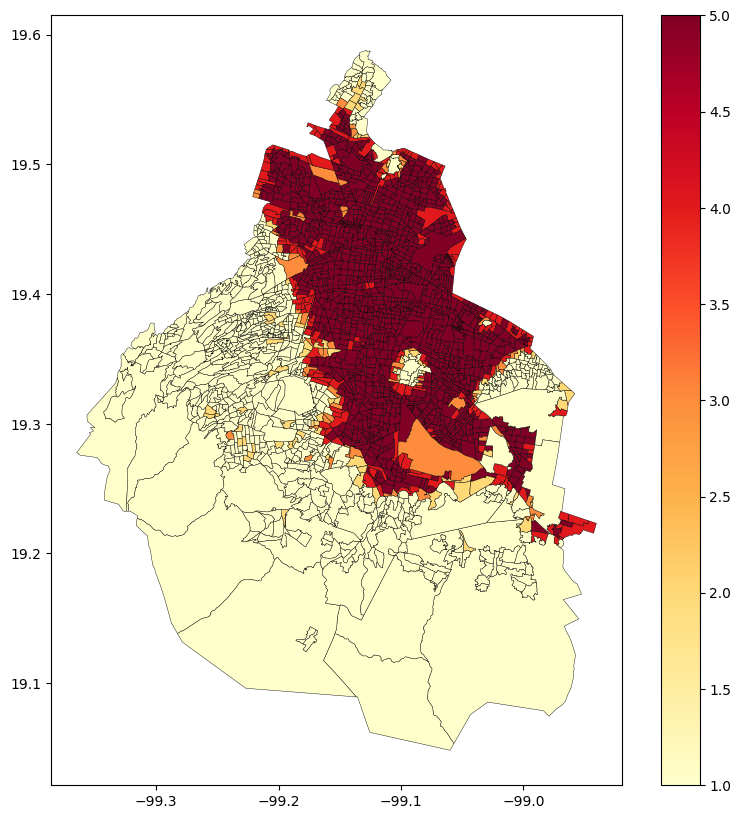

In [49]:
inundaciones_ageb_unico['geometry'] = inundaciones_ageb_unico['geo_shape'].apply(parse_geometry)

inundaciones_gdf = gpd.GeoDataFrame(inundaciones_ageb_unico, geometry='geometry')

inundaciones_gdf.crs = "EPSG:4326"

inundaciones_gdf.plot(column='int2', cmap='YlOrRd', figsize=(10, 10), edgecolor='black', linewidth=0.3, legend=True)

## Archivo Registro Único de Situaciones de Emergencia

El objetivo de este dataset es para evaluar al modelo.
En caso de que hubiera una situación de emergencia en una zona AGEB, se debería de concluir que con los niveles de riesgo indicado, concuerdan con que efectivamente hubo un incidente y que con los detalles de ese incidente se puede determinar que tan grave fue.

In [50]:
ruse = pd.read_csv("data/registro-unico-de-situaciones-de-emergencia.csv")

ruse.info()

<class 'pandas.DataFrame'>
RangeIndex: 31589 entries, 0 to 31588
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            31589 non-null  int64  
 1   geo_point_2d  31589 non-null  str    
 2   geo_shape     31589 non-null  str    
 3   folio         31589 non-null  int64  
 4   fecha         31589 non-null  str    
 5   hora          31289 non-null  str    
 6   fenomeno      31589 non-null  str    
 7   taxonomia     31588 non-null  str    
 8   grupo         31589 non-null  str    
 9   incidente     31589 non-null  str    
 10  causas        31568 non-null  str    
 11  calle_y_nu    31589 non-null  str    
 12  colonia       31586 non-null  str    
 13  alcaldia      31589 non-null  str    
 14  atendio       31586 non-null  str    
 15  atendio_dg    31571 non-null  str    
 16  fuente        31586 non-null  str    
 17  atencion      31589 non-null  str    
 18  seguimie      31554 non-null  str    

In [51]:
ruse.head()

,id,geo_point_2d,geo_shape,folio,fecha,hora,fenomeno,taxonomia,grupo,incidente,...,alcaldia,atendio,atendio_dg,fuente,atencion,seguimie,lesionados,fallecidos,latitud,longitud
0,10001,"19.31089531,-99.05992219","{""type"": ""Point"", ""coordinates"": [-99.05992219...",391,25/01/2019,21:30:00,QUIMICO-TECNOLOGICO,INCENDIO URBANO,NO APLICA,INCENDIO DE PASTO EN BALDIO O CAMELLON,...,IZTAPALAPA,"HCB, SSC","REGIONAL ORIENTE, S.-13 Y S.-30 (TIEMPO DE RES...",SSC,"EN EL PANTEON “SAN LORENZO TEZONCO”, SE SUSCIT...",NO APLICA,0,0,19.310895,-99.059922
1,10002,"19.30106176,-99.17409218","{""type"": ""Point"", ""coordinates"": [-99.17409217...",392,25/01/2019,23:35:00,QUIMICO-TECNOLOGICO,DERRAME O FUGA DE SUSTANCIA PELIGROSA,NO APLICA,FUGA DE GAS NATURAL EN TOMAS DOMICILIARIAS,...,TLALPAN,"HCB, SAC, GAS NATUTGY",NO RELEVANTE,FRECUENCIA DE RADIO,SE SUSCITO FUGA DE GAS NATURAL EN TUBERIA DE A...,NO APLICA,0,0,19.301062,-99.174092
2,10008,"19.33917957,-99.31114328","{""type"": ""Point"", ""coordinates"": [-99.31114327...",398,26/01/2019,12:38:00,SOCIORGANIZATIVO,ACCIDENTES TERRESTRES,NO APLICA,ACCIDENTES EN TRANSPORTE DE CARGA,...,CUAJIMALPA DE MORELOS,POLICIA FEDERAL,NO RELEVANTE,FRECUENCIA DE RADIO,SE TUVO CONOCIMIENTO DE LA VOLCADURA DE UN CAM...,NO APLICA,1,0,19.339180,-99.311143
3,10010,"19.33213585,-99.0767522","{""type"": ""Point"", ""coordinates"": [-99.0767522,...",400,26/01/2019,14:14:00,QUIMICO-TECNOLOGICO,INCENDIO URBANO,NO APLICA,INCENDIO EN TRANSPORTE DE CARGA,...,IZTAPALAPA,"UPC, SSC",S.-10 Y S.-16 (TIEMPO DE RESPUESTA 13 MIN.),SSC,"SOBRE LA VIA PUBLICA, A CONSECUENCIA DE CORTO ...",NO APLICA,0,0,19.332136,-99.076752
4,10014,"19.38728094,-99.13886126","{""type"": ""Point"", ""coordinates"": [-99.13886126...",404,27/01/2019,01:38:00,SOCIORGANIZATIVO,ACCIDENTES TERRESTRES,NO APLICA,ACCIDENTES EN VEHICULOS PARTICULARES,...,BENITO JUAREZ,SSC,NO RELEVANTE,SSC,"UN VEHICULO PARTICULAR, IMPACTO UNA DOVELA DE ...",NO APLICA,1,0,19.387281,-99.138861


In [52]:
ruse.duplicated().sum()

np.int64(0)

## Generación del dataset final

Para la creacion del dataset final se integran TODAS las fuentes disponibles:

- Zonas AGEB urbanas y rurales (poligonos base).
- Zonificacion geotecnica (tipo de suelo).
- Atlas de riesgo: sismo, inundacion y laderas (intensidad y area afectada).
- Fracturas geologicas (conteo y longitud por AGEB).
- Registro unico de situaciones de emergencia (RUSE).
- Indice de marginacion urbana (IMU 2020) y poblacion.

Las columnas relevantes incluyen los niveles de riesgo `int2`, porcentajes de afectacion, y variables socio-territoriales para construir un indice compuesto.

In [53]:
sismos_para_merge = sismos_ageb_unico[['cvegeo', 'int2', 'pct_afectacion_sismo']].rename(
    columns={'int2': 'riesgo_sismo'},
)

zonas_ageb_final = zonas_ageb_final.merge(
    sismos_para_merge,
    left_on='CVEGEO',
    right_on='cvegeo',
    how='left',
)

zonas_ageb_final = zonas_ageb_final.drop(columns=['cvegeo'])
zonas_ageb_final[['riesgo_sismo', 'pct_afectacion_sismo']] = zonas_ageb_final[['riesgo_sismo', 'pct_afectacion_sismo']].fillna(0)

print(f"Columnas actuales: {zonas_ageb_final.columns.tolist()}")
print(f"Total de registros: {len(zonas_ageb_final)}")
print(zonas_ageb_final[['CVEGEO', 'tipo_suelo', 'riesgo_sismo', 'pct_afectacion_sismo']].head())

Columnas actuales: ['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'CVE_LOC', 'CVE_AGEB', 'geometry', 'area_total', 'tipo_suelo', 'riesgo_sismo', 'pct_afectacion_sismo']
Total de registros: 2453
          CVEGEO  tipo_suelo  riesgo_sismo  pct_afectacion_sismo
0  0901500010023         3.0           5.0             88.364082
1  0901500010466         3.0           5.0             88.376094
2  0901500010926         3.0           4.0             88.401581
3  0901500011229         3.0           5.0             88.421940
4  0901500011290         3.0           5.0             88.419211


In [54]:
inundaciones_para_merge = inundaciones_ageb_unico[['cvegeo', 'int2', 'intens_num_limpia', 'pct_afectacion_inundacion']].rename(
    columns={
        'int2': 'riesgo_inundacion',
        'intens_num_limpia': 'severidad_inundacion'
    }
)

zonas_ageb_final = zonas_ageb_final.merge(
    inundaciones_para_merge,
    left_on='CVEGEO',
    right_on='cvegeo',
    how='left'
)

zonas_ageb_final = zonas_ageb_final.drop(columns=['cvegeo'])
cols_llenar = ['riesgo_inundacion', 'severidad_inundacion', 'pct_afectacion_inundacion']
zonas_ageb_final[cols_llenar] = zonas_ageb_final[cols_llenar].fillna(0)



Como el modelo será supervisado, se debe de generar una etiqueta final que se va a definir de la siguiente manera:

1. Las columnas de riesgo_inundacion y riesgo_sismo pueden llegar a tener valores entre 1 y 5, por lo que al sumarse, puede haber un valor máximo de 10.

2. A partir de esto se puede generar un "semáforo de riesgo" que tiene la siguiente escala:
    * Nivel de riesgo Bajo: Para valores entre 1 a 2.
    * Nivel de riesgo Bajo-Medio: Para valores entre 3 a 4.
    * Nivel de riesgo Medio: Para valores entre 5 a 6.
    * Nivel de riesgo Medio/Alto: Para valores entre 7 y 8.
    * Nivel de riesgo Alto: Para valores entre 9 y 10.

Y para que el modelo pueda trabajar con esta información de mejor manera, se manejará de forma numérica donde:
* Bajo se representa con el número 1.
* Bajo se representa con el número 2.
* Bajo se representa con el número 3.
* Medio se representa con el número 4.
* Alto se representa con el número 5.

In [55]:
# --- Laderas ---
laderas = pd.read_csv("data/atlas-de-riesgo-susceptibilidad-por-laderas.csv")
laderas['cve_mun'] = laderas['cvegeo'].str.slice(2, 5)
laderas_alcaldias = laderas[laderas['cve_mun'].isin(alcaldias_interes)].copy()
laderas_alcaldias.drop(
    columns=['fenomeno', 'taxonomia', 'r_p_v_e', 'fuente', 'alcaldia', 'entidad', 'descripcio', 'cve_mun'],
    inplace=True,
    errors='ignore',
)
laderas_final = laderas_alcaldias.merge(
    zonas_ageb_final[['CVEGEO', 'area_total']],
    left_on='cvegeo',
    right_on='CVEGEO',
    how='left',
)
laderas_final['pct_afectacion_laderas'] = (laderas_final['area_m2'] / laderas_final['area_total']) * 100
laderas_final['pct_afectacion_laderas'] = laderas_final['pct_afectacion_laderas'].clip(upper=100)
laderas_final = laderas_final.sort_values(['cvegeo', 'int2'], ascending=[True, False])
laderas_ageb_unico = laderas_final.drop_duplicates(subset='cvegeo', keep='first').copy()
laderas_ageb_unico = laderas_ageb_unico.drop(columns=['CVEGEO'])
laderas_ageb_unico = laderas_ageb_unico.rename(columns={'int2': 'riesgo_laderas'})

zonas_ageb_final = zonas_ageb_final.merge(
    laderas_ageb_unico[['cvegeo', 'riesgo_laderas', 'pct_afectacion_laderas']],
    left_on='CVEGEO',
    right_on='cvegeo',
    how='left',
)
zonas_ageb_final = zonas_ageb_final.drop(columns=['cvegeo'])

# --- RUSE ---
ruse = pd.read_csv("data/registro-unico-de-situaciones-de-emergencia.csv", low_memory=False)
ruse['latitud'] = pd.to_numeric(ruse['latitud'], errors='coerce')
ruse['longitud'] = pd.to_numeric(ruse['longitud'], errors='coerce')
ruse = ruse.dropna(subset=['latitud', 'longitud']).copy()
ruse_gdf = gpd.GeoDataFrame(
    ruse,
    geometry=gpd.points_from_xy(ruse['longitud'], ruse['latitud']),
    crs="EPSG:4326",
)
ruse_gdf = ruse_gdf.to_crs(zonas_ageb_final.crs)
ruse_join = gpd.sjoin(
    ruse_gdf,
    zonas_ageb_final[['CVEGEO', 'geometry']],
    how='inner',
    predicate='intersects',
)
ruse_counts = ruse_join.groupby('CVEGEO').size().reset_index(name='ruse_emergencias')
zonas_ageb_final = zonas_ageb_final.merge(ruse_counts, on='CVEGEO', how='left')

# --- IMU ---
imu = pd.read_csv("data/imu_2020.csv", dtype={'CVE_AGEB': str})
imu_cdmx = imu[imu['ENT'] == 9].copy()
imu_cdmx['CVEGEO'] = imu_cdmx['CVE_AGEB'].astype(str).str.zfill(13)
imu_cdmx = imu_cdmx[['CVEGEO', 'POB_TOTAL', 'IM_2020']].rename(
    columns={'POB_TOTAL': 'pob_total', 'IM_2020': 'imu_2020'}
)
imu_cdmx['pob_total'] = pd.to_numeric(imu_cdmx['pob_total'], errors='coerce')
imu_cdmx['imu_2020'] = pd.to_numeric(imu_cdmx['imu_2020'], errors='coerce')
zonas_ageb_final = zonas_ageb_final.merge(imu_cdmx, on='CVEGEO', how='left')

# --- Fracturas ---
fracturas = gpd.read_file("data/Fracturas/SPC_Estructuras_Fracturas.shp")
fracturas = fracturas.to_crs(zonas_ageb_final.crs)
fracturas_join = gpd.sjoin(
    zonas_ageb_final[['CVEGEO', 'geometry']],
    fracturas[['geometry']],
    how='left',
    predicate='intersects',
)
fracturas_count = fracturas_join.groupby('CVEGEO')['index_right'].count().reset_index(name='fracturas_count')

ageb_proj = zonas_ageb_final[['CVEGEO', 'geometry']].to_crs("EPSG:3857")
fracturas_proj = fracturas.to_crs("EPSG:3857")
fracturas_proj['length_m'] = fracturas_proj.geometry.length
fracturas_len = gpd.sjoin(
    ageb_proj,
    fracturas_proj[['geometry', 'length_m']],
    how='left',
    predicate='intersects',
)
fracturas_len = fracturas_len.groupby('CVEGEO')['length_m'].sum().reset_index(name='fracturas_longitud_m')

zonas_ageb_final = zonas_ageb_final.merge(fracturas_count, on='CVEGEO', how='left')
zonas_ageb_final = zonas_ageb_final.merge(fracturas_len, on='CVEGEO', how='left')

# --- Limpieza basica de nuevos campos ---
cols_fill_zero = [
    'riesgo_laderas', 'pct_afectacion_laderas', 'ruse_emergencias',
    'fracturas_count', 'fracturas_longitud_m'
]
for col in cols_fill_zero:
    if col in zonas_ageb_final.columns:
        zonas_ageb_final[col] = zonas_ageb_final[col].fillna(0)

cols_fill_median = ['pob_total', 'imu_2020']
for col in cols_fill_median:
    if col in zonas_ageb_final.columns:
        zonas_ageb_final[col] = zonas_ageb_final[col].fillna(zonas_ageb_final[col].median())

zonas_ageb_final['riesgo_sismo'] = pd.to_numeric(zonas_ageb_final['riesgo_sismo'], errors='coerce').fillna(0)
zonas_ageb_final['riesgo_inundacion'] = pd.to_numeric(zonas_ageb_final['riesgo_inundacion'], errors='coerce').fillna(0)
zonas_ageb_final['riesgo_laderas'] = pd.to_numeric(zonas_ageb_final['riesgo_laderas'], errors='coerce').fillna(0)
zonas_ageb_final['tipo_suelo'] = pd.to_numeric(zonas_ageb_final['tipo_suelo'], errors='coerce').fillna(0)

zonas_ageb_final['suma_riesgos'] = (
    zonas_ageb_final['riesgo_sismo'] + zonas_ageb_final['riesgo_inundacion'] + zonas_ageb_final['riesgo_laderas']
 )

# Etiquetas por intensidad
riesgo_labels = {1: 'Muy Bajo', 2: 'Bajo', 3: 'Medio', 4: 'Alto', 5: 'Muy Alto'}
zonas_ageb_final['riesgo_sismo_label'] = zonas_ageb_final['riesgo_sismo'].map(riesgo_labels).fillna('Sin dato')
zonas_ageb_final['riesgo_inundacion_label'] = zonas_ageb_final['riesgo_inundacion'].map(riesgo_labels).fillna('Sin dato')
zonas_ageb_final['riesgo_laderas_label'] = zonas_ageb_final['riesgo_laderas'].map(riesgo_labels).fillna('Sin dato')

# Normalizacion y riesgo compuesto
def minmax(series):
    minimo = series.min()
    maximo = series.max()
    if pd.isna(minimo) or pd.isna(maximo) or maximo == minimo:
        return pd.Series(0.0, index=series.index)
    return (series - minimo) / (maximo - minimo)

zonas_ageb_final['riesgo_sismo_norm'] = minmax(zonas_ageb_final['riesgo_sismo'])
zonas_ageb_final['riesgo_inundacion_norm'] = minmax(zonas_ageb_final['riesgo_inundacion'])
zonas_ageb_final['riesgo_laderas_norm'] = minmax(zonas_ageb_final['riesgo_laderas'])
zonas_ageb_final['fracturas_norm'] = minmax(zonas_ageb_final['fracturas_count'])
zonas_ageb_final['imu_norm'] = minmax(zonas_ageb_final['imu_2020'])
zonas_ageb_final['ruse_norm'] = minmax(zonas_ageb_final['ruse_emergencias'])
zonas_ageb_final['tipo_suelo_norm'] = minmax(zonas_ageb_final['tipo_suelo'])

zonas_ageb_final['indice_riesgo_compuesto'] = (
    0.22 * zonas_ageb_final['riesgo_sismo_norm']
    + 0.22 * zonas_ageb_final['riesgo_inundacion_norm']
    + 0.18 * zonas_ageb_final['fracturas_norm']
    + 0.12 * zonas_ageb_final['riesgo_laderas_norm']
    + 0.10 * zonas_ageb_final['imu_norm']
    + 0.08 * zonas_ageb_final['ruse_norm']
    + 0.08 * zonas_ageb_final['tipo_suelo_norm']
 )

zonas_ageb_final['riesgo_general'] = pd.qcut(
    zonas_ageb_final['indice_riesgo_compuesto'],
    5,
    labels=[1, 2, 3, 4, 5],
    duplicates='drop',
)
zonas_ageb_final['riesgo_general'] = zonas_ageb_final['riesgo_general'].astype(float).fillna(0).astype(int)
riesgo_general_labels = {1: 'Bajo', 2: 'Bajo-Medio', 3: 'Medio', 4: 'Medio-Alto', 5: 'Alto'}
zonas_ageb_final['riesgo_general_label'] = zonas_ageb_final['riesgo_general'].map(riesgo_general_labels).fillna('Sin dato')

print(f"Columnas actuales: {zonas_ageb_final.columns.tolist()}")
print(zonas_ageb_final[['CVEGEO', 'riesgo_sismo', 'riesgo_inundacion', 'riesgo_laderas', 'indice_riesgo_compuesto', 'riesgo_general']].head())

Columnas actuales: ['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'CVE_LOC', 'CVE_AGEB', 'geometry', 'area_total', 'tipo_suelo', 'riesgo_sismo', 'pct_afectacion_sismo', 'riesgo_inundacion', 'severidad_inundacion', 'pct_afectacion_inundacion', 'riesgo_laderas', 'pct_afectacion_laderas', 'ruse_emergencias', 'pob_total', 'imu_2020', 'fracturas_count', 'fracturas_longitud_m', 'suma_riesgos', 'riesgo_sismo_label', 'riesgo_inundacion_label', 'riesgo_laderas_label', 'riesgo_sismo_norm', 'riesgo_inundacion_norm', 'riesgo_laderas_norm', 'fracturas_norm', 'imu_norm', 'ruse_norm', 'tipo_suelo_norm', 'indice_riesgo_compuesto', 'riesgo_general', 'riesgo_general_label']
          CVEGEO  riesgo_sismo  riesgo_inundacion  riesgo_laderas  \
0  0901500010023           5.0                5.0             1.0   
1  0901500010466           5.0                5.0             1.0   
2  0901500010926           4.0                5.0             1.0   
3  0901500011229           5.0                5.0             1.0   
4  0

array([[<Axes: title={'center': 'riesgo_general'}>]], dtype=object)

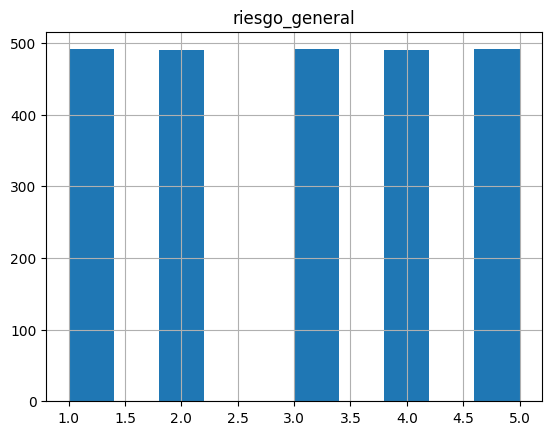

In [56]:
zonas_ageb_final.hist('riesgo_general')

In [57]:
# Copia de trabajo para limpieza (no modifica el dataset base)
zonas_ageb_clean = zonas_ageb_final.copy()

# Limpieza de datos
print("Estado inicial")
print(f"Filas: {zonas_ageb_clean.shape[0]}")
print(f"Columnas: {zonas_ageb_clean.shape[1]}")
print("Nulos totales:", int(zonas_ageb_clean.isna().sum().sum()))
print("Duplicados completos:", int(zonas_ageb_clean.duplicated().sum()))
if "CVEGEO" in zonas_ageb_clean.columns:
    print("Duplicados por CVEGEO:", int(zonas_ageb_clean.duplicated(subset="CVEGEO").sum()))

# 1) Normalizacion de registros de texto
columnas_texto = [
    c for c in zonas_ageb_clean.select_dtypes(include=["object"]).columns
    if c.lower() not in {"geometry", "geometria"}
]
for columna in columnas_texto:
    zonas_ageb_clean[columna] = zonas_ageb_clean[columna].astype(str).str.strip()
    if columna.upper() == "CVEGEO":
        zonas_ageb_clean[columna] = zonas_ageb_clean[columna].str.upper()

# 2) Eliminar duplicados
zonas_ageb_clean = zonas_ageb_clean.drop_duplicates()
if "CVEGEO" in zonas_ageb_clean.columns:
    zonas_ageb_clean = zonas_ageb_clean.drop_duplicates(subset="CVEGEO", keep="first")

# 3) Manejo de nulos
columnas_numericas = zonas_ageb_clean.select_dtypes(include=["number"]).columns.tolist()
columnas_categoricas = [
    c for c in zonas_ageb_clean.columns
    if c not in columnas_numericas and c.lower() not in {"geometry", "geometria"}
]

for columna in columnas_numericas:
    mediana = zonas_ageb_clean[columna].median()
    zonas_ageb_clean[columna] = zonas_ageb_clean[columna].fillna(mediana)

for columna in columnas_categoricas:
    if zonas_ageb_clean[columna].isna().any():
        moda = zonas_ageb_clean[columna].mode(dropna=True)
        if len(moda) > 0:
            zonas_ageb_clean[columna] = zonas_ageb_clean[columna].fillna(moda.iloc[0])

# 4) Outliers: clipping por IQR solo si hay dispersion real
columnas_continuas = [
    c for c in [
        "area_total",
        "pct_afectacion_sismo",
        "pct_afectacion_inundacion",
        "pct_afectacion_laderas",
        "fracturas_longitud_m",
        "ruse_emergencias",
        "pob_total",
        "imu_2020",
        "indice_riesgo_compuesto",
    ]
    if c in zonas_ageb_clean.columns
]

for columna in columnas_continuas:
    q1 = zonas_ageb_clean[columna].quantile(0.25)
    q3 = zonas_ageb_clean[columna].quantile(0.75)
    iqr = q3 - q1
    if pd.notna(iqr) and iqr > 0:
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr
        zonas_ageb_clean[columna] = zonas_ageb_clean[columna].clip(lower=lim_inf, upper=lim_sup)

# 5) Normalizacion Min-Max en columnas continuas
for columna in columnas_continuas:
    minimo = zonas_ageb_clean[columna].min()
    maximo = zonas_ageb_clean[columna].max()
    nuevo_nombre = f"{columna}_norm"
    if nuevo_nombre in zonas_ageb_clean.columns:
        continue
    if pd.notna(minimo) and pd.notna(maximo) and maximo != minimo:
        zonas_ageb_clean[nuevo_nombre] = (zonas_ageb_clean[columna] - minimo) / (maximo - minimo)
    else:
        zonas_ageb_clean[nuevo_nombre] = 0.0

print("\nEstado final (zonas_ageb_clean)")
print(f"Filas: {zonas_ageb_clean.shape[0]}")
print(f"Columnas: {zonas_ageb_clean.shape[1]}")
print("Nulos totales:", int(zonas_ageb_clean.isna().sum().sum()))
print("Duplicados completos:", int(zonas_ageb_clean.duplicated().sum()))
if "CVEGEO" in zonas_ageb_clean.columns:
    print("Duplicados por CVEGEO:", int(zonas_ageb_clean.duplicated(subset="CVEGEO").sum()))

print("\nColumnas nuevas de normalizacion:")
print([c for c in zonas_ageb_clean.columns if c.endswith("_norm")])

Estado inicial
Filas: 2453
Columnas: 34
Nulos totales: 22
Duplicados completos: 0
Duplicados por CVEGEO: 0

Estado final (zonas_ageb_clean)
Filas: 2453
Columnas: 43
Nulos totales: 0
Duplicados completos: 0
Duplicados por CVEGEO: 0

Columnas nuevas de normalizacion:
['riesgo_sismo_norm', 'riesgo_inundacion_norm', 'riesgo_laderas_norm', 'fracturas_norm', 'imu_norm', 'ruse_norm', 'tipo_suelo_norm', 'area_total_norm', 'pct_afectacion_sismo_norm', 'pct_afectacion_inundacion_norm', 'pct_afectacion_laderas_norm', 'fracturas_longitud_m_norm', 'ruse_emergencias_norm', 'pob_total_norm', 'imu_2020_norm', 'indice_riesgo_compuesto_norm']


C:\Users\Jerem\AppData\Local\Temp\ipykernel_6280\3975822849.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  c for c in zonas_ageb_clean.select_dtypes(include=["object"]).columns


In [58]:
# Auditoria final de consistencia y extremos
columnas_pct = [
    c for c in [
        "pct_afectacion_sismo",
        "pct_afectacion_inundacion",
        "pct_afectacion_laderas",
    ]
    if c in zonas_ageb_clean.columns
]
columnas_riesgo = [
    "riesgo_sismo",
    "riesgo_inundacion",
    "riesgo_laderas",
    "suma_riesgos",
    "indice_riesgo_compuesto",
    "riesgo_general",
]

print("Valores unicos por columna:")
for columna in columnas_riesgo + ["tipo_suelo"]:
    if columna in zonas_ageb_clean.columns:
        print(f"- {columna}: {zonas_ageb_clean[columna].nunique()}")

print("\nFrecuencias de area_total:")
print(zonas_ageb_clean["area_total"].value_counts().head(10))

print("\nRevision de porcentajes fuera de rango [0, 100]:")
for columna in columnas_pct:
    fuera_rango = zonas_ageb_clean[(zonas_ageb_clean[columna] < 0) | (zonas_ageb_clean[columna] > 100)]
    print(f"- {columna}: {len(fuera_rango)}")

print("\nDistribucion de tipo_suelo:")
print(zonas_ageb_clean["tipo_suelo"].value_counts().sort_index())

# Mapear tipo_suelo a etiquetas legibles
mapping = {1: 'Roca', 2: 'Mixto', 3: 'Arenoso'}
zonas_ageb_clean['tipo_suelo_label'] = zonas_ageb_clean['tipo_suelo'].map(mapping)
print("\nEtiquetas `tipo_suelo` asignadas:")
print(zonas_ageb_clean['tipo_suelo_label'].value_counts())

# Mostrar algunas filas para inspeccion rapida
zonas_ageb_clean[[
    'CVEGEO',
    'tipo_suelo',
    'tipo_suelo_label',
    'area_total',
    'indice_riesgo_compuesto',
    'riesgo_general',
]].head()

Valores unicos por columna:
- riesgo_sismo: 4
- riesgo_inundacion: 6
- riesgo_laderas: 6
- suma_riesgos: 10
- indice_riesgo_compuesto: 2444
- riesgo_general: 5
- tipo_suelo: 4

Frecuencias de area_total:
area_total
768055.049389    237
189037.016295      1
417107.791809      1
250720.441422      1
566255.448577      1
228865.019259      1
119139.423691      1
263138.053354      1
437314.635228      1
308731.060047      1
Name: count, dtype: int64

Revision de porcentajes fuera de rango [0, 100]:
- pct_afectacion_sismo: 0
- pct_afectacion_inundacion: 0
- pct_afectacion_laderas: 0

Distribucion de tipo_suelo:
tipo_suelo
0.0      10
1.0     836
2.0     399
3.0    1208
Name: count, dtype: int64

Etiquetas `tipo_suelo` asignadas:
tipo_suelo_label
Arenoso    1208
Roca        836
Mixto       399
Name: count, dtype: int64


,CVEGEO,tipo_suelo,tipo_suelo_label,area_total,indice_riesgo_compuesto,riesgo_general
0,0901500010023,3.0,Arenoso,189037.016295,0.625592,5
1,0901500010466,3.0,Arenoso,417107.791809,0.628164,5
2,0901500010926,3.0,Arenoso,250720.441422,0.591383,4
3,0901500011229,3.0,Arenoso,566255.448577,0.604392,4
4,0901500011290,3.0,Arenoso,228865.019259,0.618117,5


array([[<Axes: title={'center': 'riesgo_general'}>]], dtype=object)

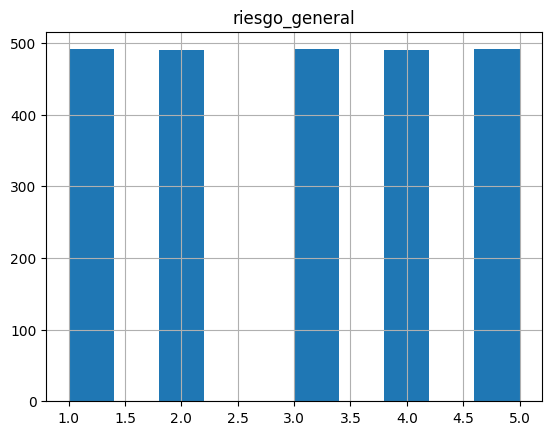

In [59]:
# Visualización final sobre la copia limpia
zonas_ageb_clean.hist('riesgo_general')


In [60]:
# Validar distribucion de riesgo_general generado por cuantiles
print(zonas_ageb_clean['riesgo_general'].value_counts().sort_index())

# Verificar rangos del indice compuesto
print(zonas_ageb_clean['indice_riesgo_compuesto'].describe())

riesgo_general
1    491
2    490
3    491
4    490
5    491
Name: count, dtype: int64
count    2453.000000
mean        0.496505
std         0.130200
min         0.042159
25%         0.355021
50%         0.557159
75%         0.614303
max         0.809936
Name: indice_riesgo_compuesto, dtype: float64


In [61]:
# Exportar la copia limpia a GeoJSON en carpeta output
import os
out_dir = "output"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "zonas_ageb_clean_v2.json")
zonas_ageb_clean.to_file(out_path, driver="GeoJSON")
print(f"Exportado zonas_ageb_clean_v2 a: {out_path}")

Exportado zonas_ageb_clean_v2 a: output\zonas_ageb_clean_v2.json


## Resumen de limpieza y justificaciones (v2)

- Cobertura total: se incorporaron AGEB urbanas y rurales para evitar sesgos de recorte.
- Integracion completa: se unieron sismo, inundacion, laderas, fracturas, RUSE e IMU a nivel AGEB.
- Indicadores nuevos: conteo y longitud de fracturas, emergencias RUSE, IMU/poblacion, riesgo por laderas.
- Riesgo compuesto: se creo `indice_riesgo_compuesto` con ponderaciones explicitas y se reetiqueto a `riesgo_general` en 5 niveles.
- Exportacion: se guardo el dataset limpio en `output/zonas_ageb_clean_v2.json` para el resto de los cuadernos.

Indicaciones para revisar o reproducir:
- Ejecutar todas las celdas desde el inicio para regenerar la salida v2.
- Revisar la celda de riesgo compuesto si se desean ajustar ponderaciones.

Notas:
- No se eliminaron filas sin justificacion; se aplico imputacion y clipping solo en columnas continuas.
- Archivos de salida: `output/zonas_ageb_clean_v2.json` (copia limpia v2).